In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Dry_Eye_Dataset.csv')
print("5 Baris Data Awal:")
print(df.head())

5 Baris Data Awal:
  Gender  Age  Sleep duration  Sleep quality  Stress level Blood pressure  \
0      F   24             9.5              2             1         137/89   
1      M   39             9.6              2             3         108/64   
2      F   45             5.4              1             5         134/81   
3      F   45             5.4              4             5         110/90   
4      F   42             5.7              3             2          99/67   

   Heart rate  Daily steps  Physical activity  Height  ...  Smoking  \
0          67         3000                 31     161  ...        N   
1          60        12000                 74     164  ...        N   
2          95        12000                 93     179  ...        N   
3          78        19000                 32     160  ...        N   
4          72         4000                173     179  ...        N   

  Medical issue Ongoing medication Smart device before bed  \
0             Y              

In [ ]:
print("Informasi Dataset:")
print(df.info())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  object 
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  object 
 12  Wake up during night         20000 non-null  object 
 1

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64


In [ ]:
print("\nDistribusi Target (Dry Eye Disease):")
print(df['Dry Eye Disease'].value_counts())


Distribusi Target (Dry Eye Disease):
Dry Eye Disease
Y    13037
N     6963
Name: count, dtype: int64


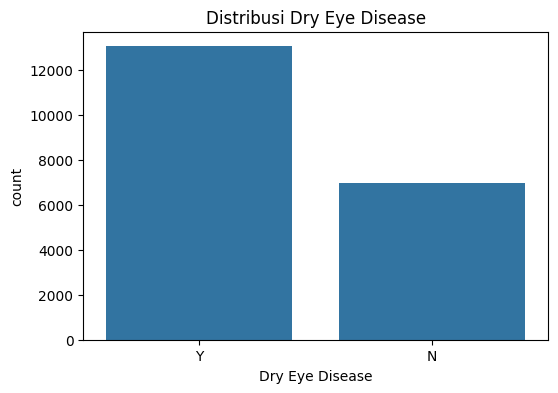

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Dry Eye Disease', order=df['Dry Eye Disease'].value_counts().index)
plt.title("Distribusi Dry Eye Disease")
plt.show()

In [ ]:
X = df.drop('Dry Eye Disease', axis=1)
y = df['Dry Eye Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
numeric_cols = X.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
if 'Blood pressure' in df.columns:
    df[['Systolic', 'Diastolic']] = df['Blood pressure'].str.split('/', expand=True).astype(int)
    df = df.drop('Blood pressure', axis=1)

binary_cols_yn = ['Sleep disorder', 'Wake up during night', 'Feel sleepy during day',
                  'Caffeine consumption', 'Alcohol consumption', 'Smoking',
                  'Medical issue', 'Ongoing medication', 'Smart device before bed',
                  'Blue-light filter', 'Discomfort Eye-strain', 'Redness in eye',
                  'Itchiness/Irritation in eye', 'Dry Eye Disease']

for col in binary_cols_yn:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'Y': 1, 'N': 0})

if 'Gender' in df.columns and df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})

print("\nData after preprocessing:")
print(df.head())


Data after preprocessing:
   Gender  Age  Sleep duration  Sleep quality  Stress level  Heart rate  \
0       0   24             9.5              2             1          67   
1       1   39             9.6              2             3          60   
2       0   45             5.4              1             5          95   
3       0   45             5.4              4             5          78   
4       0   42             5.7              3             2          72   

   Daily steps  Physical activity  Height  Weight  ...  Ongoing medication  \
0         3000                 31     161      69  ...                   1   
1        12000                 74     164      87  ...                   1   
2        12000                 93     179      94  ...                   0   
3        19000                 32     160      77  ...                   0   
4         4000                173     179      99  ...                   0   

   Smart device before bed  Average screen time  Blue

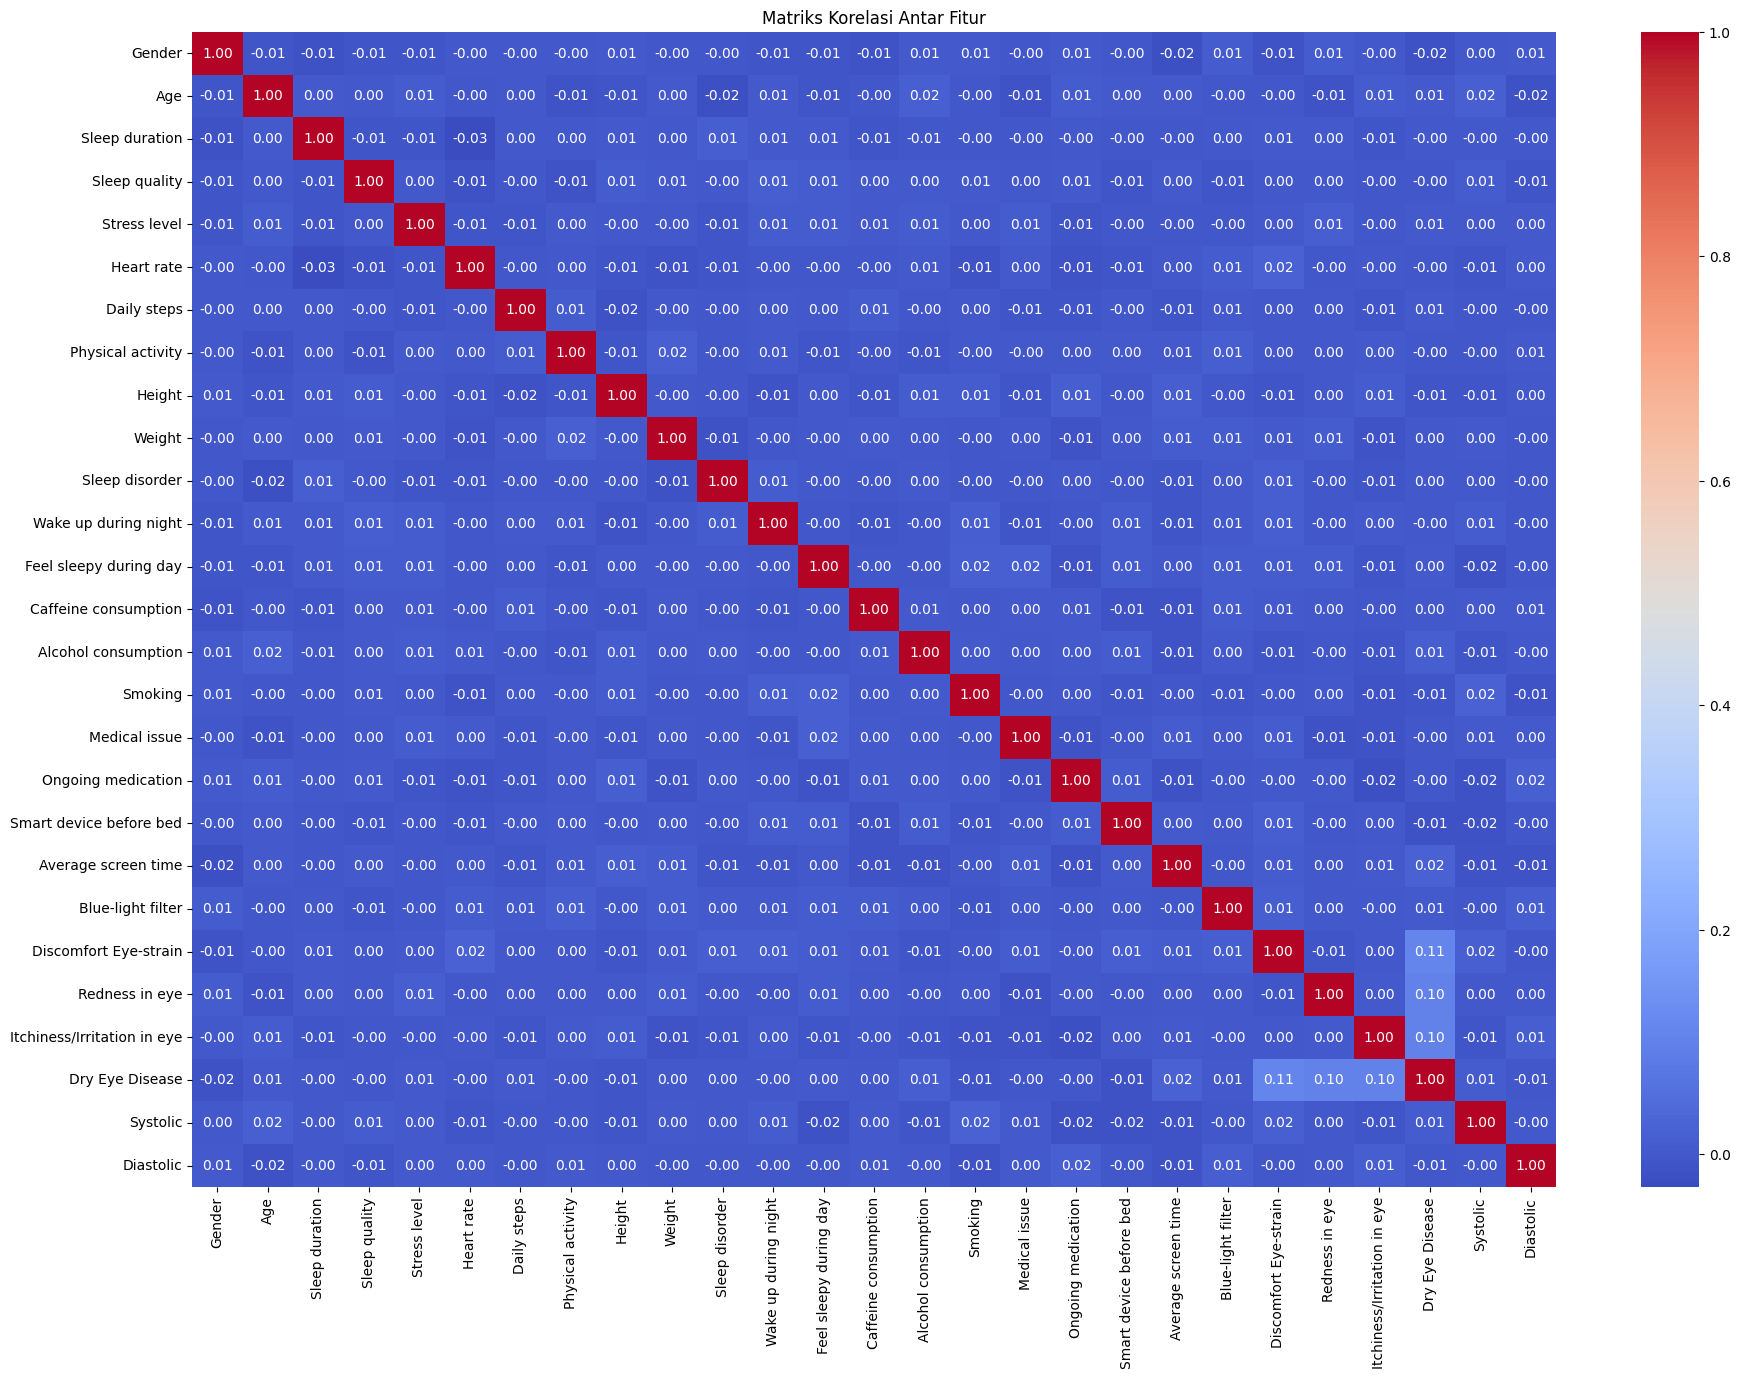

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(22, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
print("\nPenerapan Algoritma Random Forest")

rf_model = RandomForestClassifier(n_estimators=500, random_state=42)
rf_model.fit(X_train_res, y_train_res)
rf_pred = rf_model.predict(X_test)

print("Laporan Klasifikasi Random Forest:")
print(classification_report(y_test, rf_pred))
print(f"Akurasi: {accuracy_score(y_test, rf_pred):.4f}")


Penerapan Algoritma Random Forest
Laporan Klasifikasi Random Forest:
              precision    recall  f1-score   support

           0       0.68      0.25      0.37      1393
           1       0.70      0.94      0.80      2607

    accuracy                           0.70      4000
   macro avg       0.69      0.60      0.59      4000
weighted avg       0.69      0.70      0.65      4000

Akurasi: 0.6987


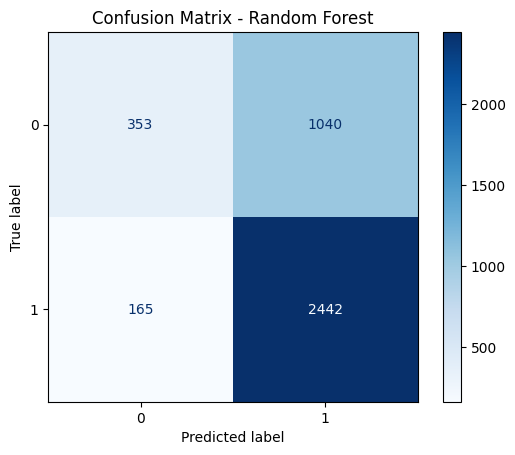

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, rf_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=[0, 1])
disp_log.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

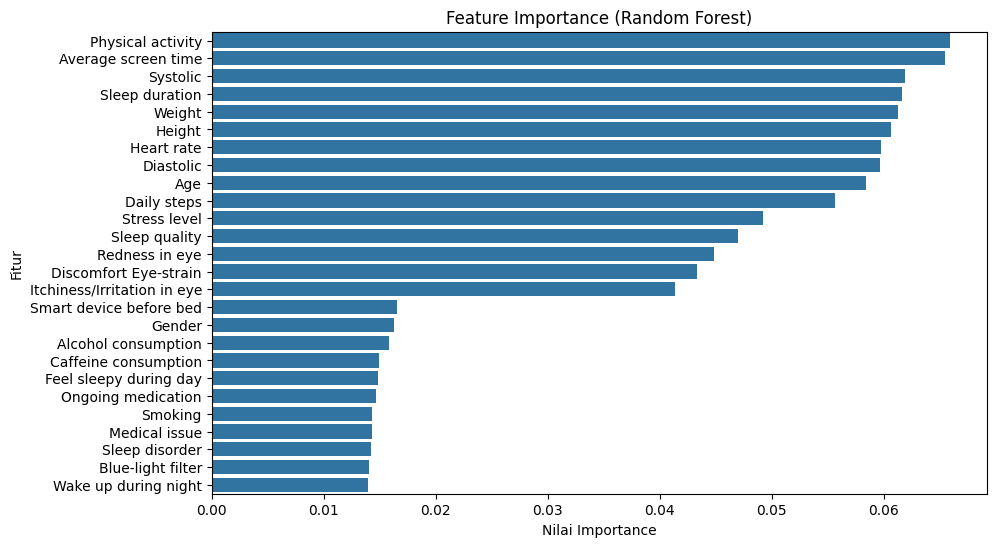

In [ ]:
feature_importances = rf_model.feature_importances_
features = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')
plt.show()